# Experiments

## Imports

In [1]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error, r2_score

# imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
import function_depot as fd

# DF7 creation

Here I need to create df7, which I may just choose to rename to be df6, but with one additonal column, 'synthetic' a dummy variable that will indicate if the dataframe is synthetic or real. That way I need not replace dataset names in my code and simply allow for the removal of all synthetic data by filtering on that variable. 

The process:
1. Merge the two data subsets so that df6 is a combination. This way I can use the same process as before to load in the spectra, the rounding and all and the only new addition is that that is the synthetic column as well.
2. Reload in the data, rounded as needed.
3. Load the new dataframes for each of the internal conditions. the fingerprints and all. 
4. Bin and threshold the large dataset appropriately. 


In [ ]:
# df6_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')

In [ ]:
# df6_subset.head()

## High Level Dataset Merger

In [25]:
# First we need to load in the two datasets. We need to remake the df6subset due to the errors before,
# to ensure everything is correct.
df6 = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/dataset_sep23.parquet')
print(df6.shape)
df6_synth = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/synthetic_spectra_2025_12_16_with_CE_clean.parquet')
print(df6_synth.shape)
df6_synth2 = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/synthetic_spectra_2.parquet')
print(df6_synth2.shape)

(24225, 21)
(413, 18)
(401, 18)


In [26]:
# Now take the subset of df6 we want and combine with the synthetic data.
# First order of business is to standardize our SMILES column. We want to use canonical smiles rather than SMILES_spectra but 
# we will keep the column name SMILES_spectra for consistency with previous code
df6 = df6.drop('SMILES_spectra', axis=1) # Drop
df6 = df6.rename(columns={'canonical_smiles_tox_vals': 'SMILES_spectra'}) # Rename
cols = df6.columns.tolist()
cols.remove('SMILES_spectra') 
df6 = df6[['SMILES_spectra'] + cols] # Move to front
# Next we want to standardize the Ionization column
# print(df6["Ionization_Mode"].unique()) # Check unique values
df6["Ionization_Mode"] = df6["Ionization_Mode"].replace("'Positive'", "'positive'") # Fix capitaliztion
df6 = df6[df6["Ionization_Mode"] != "'N/A'"] # Remove N/A 
# print(df6["Ionization_Mode"].unique()) # Check unique values

# Remove single quotes from all columns
df6 = df6.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)

# Select specific groups for subset
selected_groups = ['Q-Orbitrap-positive', 'Q-TOF-positive', 'LTQ-Orbitrap-positive']

# Create subset with only selected groups
df6_subset = df6[df6['Group'].isin(selected_groups)]

print(df6_subset.shape)

(15288, 20)


In [27]:
print(df6_subset.shape)
print(df6_synth.shape)
print(df6_synth2.shape)

(15288, 20)
(413, 18)
(401, 18)


In [28]:
print(df6_subset.columns)
print(df6_synth.columns)
print(df6_synth2.columns)

Index(['SMILES_spectra', 'CAS', 'Molecular_Formula', 'Total_Exact_Mass',
       'Precursor_m_z', 'Precursor_Type', 'Spectrum', 'Ionization_Mode',
       'Instrument_Type', 'Instrument_Name', 'Collision_Energy',
       'canonical_smiles_spectra', 'SMILES_tox', 'Response_Modifier',
       'Response', 'Response_Unit', 'Group', 'CE_clean', 'fp', 'filtered_fp'],
      dtype='object')
Index(['SMILES_spectra', 'CAS', 'Molecular_Formula', 'Total_Exact_Mass',
       'Precursor_m_z', 'Precursor_Type', 'Spectrum', 'Ionization_Mode',
       'Instrument_Type', 'Instrument_Name', 'Collision_energy',
       'Response_Modifier', 'Response', 'Response_Unit', 'Group', 'CE_clean',
       'fp', 'filtered_fp'],
      dtype='object')
Index(['SMILES_spectra', 'CAS', 'Molecular_Formula', 'Total_Exact_Mass',
       'Precursor_m_z', 'Precursor_Type', 'Spectrum', 'Ionization_Mode',
       'Instrument_Type', 'Instrument_Name', 'Collision_energy',
       'Response_Modifier', 'Response', 'Response_Unit', 'Group', '

In [20]:
df6_synth_copy = df6_synth.copy()
df6_synth2_copy = df6_synth2.copy()
print(df6_synth_copy.shape)
print(df6_synth2_copy.shape)

(413, 18)
(401, 18)


In [12]:
# Filter df6_synth to keep only rows where Collision_energy is between 30 and 45
print(f"Original df6_synth shape: {df6_synth.shape}")
print(f"Collision_energy range in df6_synth: {df6_synth['Collision_energy'].min()} to {df6_synth['Collision_energy'].max()}")

# Keep rows where Collision_energy is between 30 and 45 (inclusive)
df6_synth = df6_synth[(df6_synth['Collision_energy'] >= 30) & (df6_synth['Collision_energy'] <= 45)]

print(f"Filtered df6_synth shape: {df6_synth.shape}")
print(f"New Collision_energy range in df6_synth: {df6_synth['Collision_energy'].min()} to {df6_synth['Collision_energy'].max()}")

print("\n" + "="*50 + "\n")

# Filter df6_synth2 to keep only rows where Collision_energy is less than 80
print(f"Original df6_synth2 shape: {df6_synth2.shape}")
print(f"Collision_energy range in df6_synth2: {df6_synth2['Collision_energy'].min()} to {df6_synth2['Collision_energy'].max()}")

# Keep rows where Collision_energy is less than 80
df6_synth2 = df6_synth2[df6_synth2['Collision_energy'] < 80]

print(f"Filtered df6_synth2 shape: {df6_synth2.shape}")
print(f"New Collision_energy range in df6_synth2: {df6_synth2['Collision_energy'].min()} to {df6_synth2['Collision_energy'].max()}")

Original df6_synth shape: (413, 18)
Collision_energy range in df6_synth: 20 to 80
Filtered df6_synth shape: (236, 18)
New Collision_energy range in df6_synth: 30 to 45


Original df6_synth2 shape: (401, 18)
Collision_energy range in df6_synth2: 20 to 80
Filtered df6_synth2 shape: (347, 18)
New Collision_energy range in df6_synth2: 20 to 60


In [29]:
# Remove rows where CE_clean is 'calc' from df6
print(f"Original df6 shape: {df6_subset.shape}")
print(f"CE_clean values before filtering: {df6_subset['CE_clean'].value_counts()}")

# Filter out rows where CE_clean equals 'calc'
df6_subset = df6_subset[df6_subset['CE_clean'] != 'calc']
print(f"Filtered df6 shape: {df6_subset.shape}")
print(f"CE_clean values after filtering: {df6_subset['CE_clean'].value_counts()}")
print(f"Removed {df6_subset.shape[0]} rows where CE_clean was 'calc'")

Original df6 shape: (15288, 20)
CE_clean values before filtering: CE_clean
low       7718
medium    5142
NAN       1265
high      1161
calc         2
Name: count, dtype: int64
Filtered df6 shape: (15286, 20)
CE_clean values after filtering: CE_clean
low       7718
medium    5142
NAN       1265
high      1161
Name: count, dtype: int64
Removed 15286 rows where CE_clean was 'calc'


In [30]:
# Standardize column names - rename 'Collision_Energy' to 'Collision_energy' in df6_subset
if 'Collision_Energy' in df6_subset.columns:
    df6_subset = df6_subset.rename(columns={'Collision_Energy': 'Collision_energy'})

# Find common columns across all three dataframes
common_columns = set(df6_subset.columns) & set(df6_synth.columns) & set(df6_synth2.columns)
common_columns = list(common_columns)
print(f"Common columns: {len(common_columns)}")

# Keep only common columns in df6_subset
df6_subset = df6_subset[common_columns]

# Add synthetic column (0 for real data, 1 for synthetic data)
df6_subset['synthetic'] = 0
df6_synth['synthetic'] = 1
df6_synth2['synthetic'] = 1

print(f"df6_subset shape after processing: {df6_subset.shape}")
print(f"df6_synth shape after adding synthetic column: {df6_synth.shape}")
print(f"df6_synth2 shape after adding synthetic column: {df6_synth2.shape}")

Common columns: 18
df6_subset shape after processing: (15286, 19)
df6_synth shape after adding synthetic column: (413, 19)
df6_synth2 shape after adding synthetic column: (401, 19)


In [31]:
# Save the existing df6_subset as df6_subset_real
df6_subset_real = df6_subset.copy()
print(f"Saved original df6_subset as df6_subset_real with shape: {df6_subset_real.shape}")
# df6_subset_real.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset_real.parquet')
# Combine all three dataframes vertically into new df6_subset
df6_subset = pd.concat([df6_subset, df6_synth, df6_synth2], 
                      ignore_index=True, sort=False)

print(f"Combined dataframe shapes:")
print(f"  df6_subset_real: {df6_subset_real.shape}")
print(f"  df6_synth: {df6_synth.shape}") 
print(f"  df6_synth2: {df6_synth2.shape}")
print(f"  New combined df6_subset: {df6_subset.shape}")

# Verify synthetic column distribution
print(f"\nSynthetic column distribution in new df6_subset:")
print(df6_subset['synthetic'].value_counts())

Saved original df6_subset as df6_subset_real with shape: (15286, 19)
Combined dataframe shapes:
  df6_subset_real: (15286, 19)
  df6_synth: (413, 19)
  df6_synth2: (401, 19)
  New combined df6_subset: (16100, 19)

Synthetic column distribution in new df6_subset:
synthetic
0    15286
1      814
Name: count, dtype: int64


In [39]:
print(df6_subset.shape)
df6_subset.head()
df6_subset.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')

(16100, 6)


In [37]:
# Define the desired column order
desired_columns = ['SMILES_spectra',  'Response', 'Group', 'CE_clean',
                   'fp', 'filtered_fp']

# Check which columns exist in df6_subset
existing_columns = [col for col in desired_columns if col in df6_subset.columns]
missing_columns = [col for col in desired_columns if col not in df6_subset.columns]

print(f"Existing columns: {len(existing_columns)}")
print(f"Missing columns: {missing_columns}")

# Reorder df6_subset with existing columns only
df6_subset = df6_subset[existing_columns]

print(f"df6_subset reordered with shape: {df6_subset.shape}")
print(f"New column order: {list(df6_subset.columns)}")

Existing columns: 6
Missing columns: []
df6_subset reordered with shape: (16100, 6)
New column order: ['SMILES_spectra', 'Response', 'Group', 'CE_clean', 'fp', 'filtered_fp']


# Testing!

In [40]:
# Load both dataframes
df6_spectra = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')
df6_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')

print(f"df6_spectra shape: {df6_spectra.shape}")
print(f"df6_subset shape: {df6_subset.shape}")

# Get unique SMILES from both dataframes
spectra_smiles = set(df6_spectra['SMILES_spectra'].unique())
subset_smiles = set(df6_subset['SMILES_spectra'].unique())

print(f"\nUnique SMILES in df6_spectra: {len(spectra_smiles)}")
print(f"Unique SMILES in df6_subset: {len(subset_smiles)}")

# Find common SMILES
common_smiles = spectra_smiles & subset_smiles
print(f"Common SMILES between both datasets: {len(common_smiles)}")

# Find SMILES only in df6_spectra
only_in_spectra = spectra_smiles - subset_smiles
print(f"SMILES only in df6_spectra: {len(only_in_spectra)}")

# Find SMILES only in df6_subset
only_in_subset = subset_smiles - spectra_smiles
print(f"SMILES only in df6_subset: {len(only_in_subset)}")

# Show some examples if there are differences
if only_in_spectra:
    print(f"\nFirst 5 SMILES only in df6_spectra:")
    for smiles in list(only_in_spectra)[:5]:
        print(f"  {smiles}")

if only_in_subset:
    print(f"\nFirst 5 SMILES only in df6_subset:")
    for smiles in list(only_in_subset)[:5]:
        print(f"  {smiles}")

# Check if datasets are perfectly aligned
if len(only_in_spectra) == 0 and len(only_in_subset) == 0:
    print(f"\n✓ PERFECT MATCH: Both datasets have exactly the same unique SMILES")
else:
    print(f"\n✗ MISMATCH: Datasets have different SMILES entries")

# Additional analysis: Check row counts per SMILES
print(f"\n=== ROW COUNT ANALYSIS ===")
spectra_counts = df6_spectra['SMILES_spectra'].value_counts()
subset_counts = df6_subset['SMILES_spectra'].value_counts()

print(f"SMILES with multiple rows in df6_spectra: {sum(spectra_counts > 1)}")
print(f"SMILES with multiple rows in df6_subset: {sum(subset_counts > 1)}")

# For common SMILES, compare row counts
if common_smiles:
    print(f"\n=== ROW COUNT COMPARISON FOR COMMON SMILES ===")
    count_mismatches = 0
    for smiles in list(common_smiles)[:10]:  # Check first 10 common SMILES
        spectra_count = spectra_counts.get(smiles, 0)
        subset_count = subset_counts.get(smiles, 0)
        if spectra_count != subset_count:
            count_mismatches += 1
            print(f"  {smiles}: df6_spectra={spectra_count}, df6_subset={subset_count}")
    
    if count_mismatches == 0:
        print("  ✓ Row counts match for all common SMILES (checked first 10)")
    else:
        print(f"  ✗ Row count mismatches found for {count_mismatches} SMILES")

# Summary statistics
print(f"\n=== SUMMARY ===")
print(f"Total unique SMILES across both datasets: {len(spectra_smiles | subset_smiles)}")
print(f"Overlap percentage: {len(common_smiles) / len(spectra_smiles | subset_smiles) * 100:.2f}%")

df6_spectra shape: (15869, 54914)
df6_subset shape: (16100, 6)

Unique SMILES in df6_spectra: 1419
Unique SMILES in df6_subset: 1419
Common SMILES between both datasets: 1419
SMILES only in df6_spectra: 0
SMILES only in df6_subset: 0

✓ PERFECT MATCH: Both datasets have exactly the same unique SMILES

=== ROW COUNT ANALYSIS ===
SMILES with multiple rows in df6_spectra: 1255
SMILES with multiple rows in df6_subset: 1255

=== ROW COUNT COMPARISON FOR COMMON SMILES ===
  CCOC(=O)C1(c2ccccc2)CCN(C)CC1: df6_spectra=16, df6_subset=20
  ✗ Row count mismatches found for 1 SMILES

=== SUMMARY ===
Total unique SMILES across both datasets: 1419
Overlap percentage: 100.00%


In [24]:
print(df6_spectra['synthetic'].value_counts())

synthetic
0    15286
1      583
Name: count, dtype: int64


## Internal conditions dataframes

In [ ]:
# # CHEMNET EMBEDDINGS
# # Create ChemNet embeddings dataframe using get_chemnet_emb_from_smiles
# unique_smiles = df6_subset['SMILES_spectra'].unique().tolist()
# print(f"Getting ChemNet embeddings for {len(unique_smiles)} unique SMILES...")

# # Get embeddings dictionary
# embeddings_dict = fd.get_chemnet_emb_from_smiles(unique_smiles)

# # Convert to dataframe format
# embeddings_data = []
# for smiles, embedding in embeddings_dict.items():
#     if embedding != 'unknown':  # Skip unknown embeddings
#         row = {'SMILES_spectra': smiles}
#         # Add each embedding dimension as a separate column
#         for i, emb_val in enumerate(embedding):
#             row[f'Embedding Float {i}'] = emb_val
#         embeddings_data.append(row)

# df6_chemnet = pd.DataFrame(embeddings_data)

# print("\n=== EMBEDDINGS DATAFRAME ===")
# print(f"Shape: {df6_chemnet.shape}")
# print(f"Unique SMILES: {df6_chemnet['SMILES_spectra'].nunique()}")
# print(f"Embedding dimensions: {df6_chemnet.shape[1] - 1}")  # -1 for SMILES column

# # MORGAN FINGERPRINTS
# # Create dataframe with just SMILES and Morgan fingerprints using expand_fingerprints_to_matrix
# df6_morganfp= fd.expand_fingerprints_to_matrix(df6_subset, smiles_col='SMILES_spectra', fp_col='fp')

# print("\n=== FINGERPRINTS DATAFRAME ===")
# print(f"Shape: {df6_morganfp.shape}")
# print(f"Unique SMILES: {df6_morganfp['SMILES_spectra'].nunique()}")

# # FILTERED MORGAN FINGERPRINTS
# # Create dataframe with just SMILES and Morgan fingerprints using expand_fingerprints_to_matrix
# df6_filtered_morganfp= fd.expand_fingerprints_to_matrix(df6_subset, smiles_col='SMILES_spectra', fp_col='filtered_fp')

# print("\n=== FINGERPRINTS DATAFRAME ===")
# print(f"Shape: {df6_filtered_morganfp.shape}")
# print(f"Unique SMILES: {df6_filtered_morganfp['SMILES_spectra'].nunique()}")

In [ ]:
# df6_chemnet.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet.parquet', index=False)
# df6_morganfp.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp.parquet', index=False)
# df6_filtered_morganfp.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp.parquet', index=False)

In [ ]:
# df6_chemnet = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet.parquet')
# print(df6_chemnet.shape)
# df6_chemnet.head()

In [ ]:
# df6_morganfp = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp.parquet')
# print(df6_morganfp.shape)
# df6_morganfp.head()

In [ ]:
# df6_filtered_morganfp = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp.parquet')
# print(df6_filtered_morganfp.shape) 
# df6_filtered_morganfp.head()

## Set up spectra dataframe

In [ ]:
def pre_filter_and_round_spectrum_mz_synth(df, spectrum_col, min_mz=0, max_mz=1000, round_precision=0.001):
    """
    Pre-filter a DataFrame by removing m/z values outside the specified range AND round m/z values 
    to the nearest specified precision from spectrum strings.
    This reduces memory usage before processing with spectrum_string_to_dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame with spectrum data
    spectrum_col : str
        Name of the column containing spectrum strings
    min_mz : float, optional
        Minimum m/z value to keep. Default is 0.
    max_mz : float, optional
        Maximum m/z value to keep. Default is 1000.
    round_precision : float, optional
        Precision to round m/z values to. Default is 0.001.
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with filtered and rounded spectrum strings
    """
    def filter_and_round_spectrum_string_synth(spectrum_str, min_mz, max_mz, round_precision):
        if pd.isna(spectrum_str):
            return ""
        
        pairs = spectrum_str.split()
        filtered_pairs = []
        
        for pair in pairs:
            try:
                x, y = pair.split(":")
                mz_value = float(x)
                
                # First filter by range
                if min_mz <= mz_value <= max_mz:
                    # Then round to specified precision
                    rounded_mz = round(mz_value / round_precision) * round_precision
                    # Format to avoid floating point precision issues
                    rounded_mz_str = f"{rounded_mz:.3f}"
                    
                    # CHANGE: Multiply intensity by 100 to correct scale before reconstruction
                    intensity_corrected = float(y) * 100
                    filtered_pairs.append(f"{rounded_mz_str}:{intensity_corrected}")
            except:
                continue
        
        return " ".join(filtered_pairs)
    
    df_filtered = df.copy()
    print(f"Filtering {len(df)} rows, keeping m/z values between {min_mz} and {max_mz}, rounding to nearest {round_precision}...")
    df_filtered[spectrum_col] = df_filtered[spectrum_col].apply(
        lambda x: filter_and_round_spectrum_string_synth(x, min_mz, max_mz, round_precision)
    )
    print("Filtering and rounding complete.")
    
    return df_filtered

In [ ]:
df6_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')
df6_synth = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_synth.parquet')
df6_synth2 = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_synth2.parquet')


In [ ]:
# SPECTRA DATAFRAME
print("Creating spectra dataframe...")
# Create dataframe with spectra using spectrum_string_to_dataframe
df_filtered = fd.pre_filter_and_round_spectrum_mz(df=df6_subset, spectrum_col='Spectrum',min_mz=0, max_mz=1500, round_precision=0.01)
print("Starting conversion of spectrum strings to dataframe...")
df6_spectra = fd.spectrum_string_to_dataframe(df_filtered, spectrum_col='Spectrum', smiles_col='SMILES_spectra')

# SYNTH SPECTRA DATAFRAME
print("Creating spectra dataframe...")
# Create dataframe with spectra using spectrum_string_to_dataframe
df_filtered_synth = pre_filter_and_round_spectrum_mz_synth(df=df6_synth, spectrum_col='Spectrum',min_mz=0, max_mz=1500, round_precision=0.01)
print("Starting conversion of spectrum strings to dataframe...")
df6_spectra_synth = fd.spectrum_string_to_dataframe(df_filtered_synth, spectrum_col='Spectrum', smiles_col='SMILES_spectra')

# SYNTH2 SPECTRA DATAFRAME
print("Creating spectra dataframe...")
# Create dataframe with spectra using spectrum_string_to_dataframe
df_filtered_synth2 = pre_filter_and_round_spectrum_mz_synth(df=df6_synth2, spectrum_col='Spectrum',min_mz=0, max_mz=1500, round_precision=0.01)
print("Starting conversion of spectrum strings to dataframe...")
df6_spectra_synth2 = fd.spectrum_string_to_dataframe(df_filtered_synth2, spectrum_col='Spectrum', smiles_col='SMILES_spectra')

In [ ]:
# Add columns back to df6_spectra from df6_subset
df6_spectra['Group'] = df6_subset['Group'].values
df6_spectra['Response'] = df6_subset['Response'].values
df6_spectra['CE_clean'] = df6_subset['CE_clean'].values
df6_spectra['synthetic'] = df6_subset['synthetic'].values

# Add columns back to df6_spectra_synth from df6_synth
df6_spectra_synth['Group'] = df6_synth['Group'].values
df6_spectra_synth['Response'] = df6_synth['Response'].values
df6_spectra_synth['CE_clean'] = df6_synth['CE_clean'].values
df6_spectra_synth['synthetic'] = df6_synth['synthetic'].values

# Add columns back to df6_spectra_synth2 from df6_synth2
df6_spectra_synth2['Group'] = df6_synth2['Group'].values
df6_spectra_synth2['Response'] = df6_synth2['Response'].values
df6_spectra_synth2['CE_clean'] = df6_synth2['CE_clean'].values
df6_spectra_synth2['synthetic'] = df6_synth2['synthetic'].values

print("Columns added back to all spectra dataframes:")
print(f"df6_spectra shape: {df6_spectra.shape}")
print(f"df6_spectra_synth shape: {df6_spectra_synth.shape}")
print(f"df6_spectra_synth2 shape: {df6_spectra_synth2.shape}")

In [ ]:
print(df6_spectra.shape)
print(df6_spectra_synth.shape)
print(df6_spectra_synth2.shape)

In [ ]:
df6_spectra.head()

In [ ]:
df6_spectra_synth.head()

In [ ]:
df6_spectra_synth2.head()

In [ ]:
# Remove index_id column from each of the three datasets
if 'index_id' in df6_spectra.columns:
    df6_spectra = df6_spectra.drop('index_id', axis=1)
    print("Removed index_id from df6_spectra")

if 'index_id' in df6_spectra_synth.columns:
    df6_spectra_synth = df6_spectra_synth.drop('index_id', axis=1)
    print("Removed index_id from df6_spectra_synth")

if 'index_id' in df6_spectra_synth2.columns:
    df6_spectra_synth2 = df6_spectra_synth2.drop('index_id', axis=1)
    print("Removed index_id from df6_spectra_synth2")

In [ ]:
# Define metadata columns to preserve
metadata_columns = ['SMILES_spectra', 'Group', 'CE_clean', 'Response', 'synthetic']

# Get all unique spectral columns (excluding metadata columns)
all_spectral_columns = set()
for df in [df6_spectra, df6_spectra_synth, df6_spectra_synth2]:
    spectral_cols = [col for col in df.columns if col not in metadata_columns]
    all_spectral_columns.update(spectral_cols)

# Convert spectral column names to floats and sort numerically from low to high
def sort_key(col):
    try:
        return float(col)
    except:
        return float('inf')  # Put non-numeric columns at the end

all_spectral_columns = sorted(list(all_spectral_columns), key=sort_key)

# Convert column names to floats where possible
float_spectral_columns = []
for col in all_spectral_columns:
    try:
        float_spectral_columns.append(float(col))
    except:
        float_spectral_columns.append(col)  # Keep original if can't convert

# Add missing spectral columns to each dataframe and fill with zeros
for i, col in enumerate(all_spectral_columns):
    float_col = float_spectral_columns[i]
    if col not in df6_spectra.columns:
        df6_spectra[float_col] = 0.0
    else:
        df6_spectra[float_col] = df6_spectra[col].astype(float)
        if col != float_col:
            df6_spectra = df6_spectra.drop(col, axis=1)
    
    if col not in df6_spectra_synth.columns:
        df6_spectra_synth[float_col] = 0.0
    else:
        df6_spectra_synth[float_col] = df6_spectra_synth[col].astype(float)
        if col != float_col:
            df6_spectra_synth = df6_spectra_synth.drop(col, axis=1)
    
    if col not in df6_spectra_synth2.columns:
        df6_spectra_synth2[float_col] = 0.0
    else:
        df6_spectra_synth2[float_col] = df6_spectra_synth2[col].astype(float)
        if col != float_col:
            df6_spectra_synth2 = df6_spectra_synth2.drop(col, axis=1)

# Create final column order: metadata columns first, then sorted float spectral columns
final_column_order = metadata_columns + float_spectral_columns

# Reorder columns to be consistent across all dataframes
df6_spectra = df6_spectra[final_column_order]
df6_spectra_synth = df6_spectra_synth[final_column_order]
df6_spectra_synth2 = df6_spectra_synth2[final_column_order]

# Combine all three dataframes vertically
df6_spectra_combined = pd.concat([df6_spectra, df6_spectra_synth, df6_spectra_synth2], 
                                ignore_index=True, sort=False)

print(f"Combined dataframe shape: {df6_spectra_combined.shape}")
print(f"Total rows: {len(df6_spectra)} + {len(df6_spectra_synth)} + {len(df6_spectra_synth2)} = {len(df6_spectra_combined)}")
print(f"Total spectral columns: {len(float_spectral_columns)}")
print(f"Total columns (including metadata): {len(final_column_order)}")
print(f"Spectral columns range from {min(float_spectral_columns)} to {max(float_spectral_columns)}")

# Add new index_id to the combined dataframe
df6_spectra_combined['index_id'] = range(len(df6_spectra_combined))

print(f"Added new index_id to combined dataframe with range 0 to {len(df6_spectra_combined)-1}")
print(f"Final combined dataframe shape: {df6_spectra_combined.shape}")

In [ ]:
# Move Group, CE_clean, Response, and synthetic columns to the end
columns_to_move = ['Group', 'CE_clean', 'Response', 'synthetic']
other_columns = [col for col in df6_spectra_combined.columns if col not in columns_to_move]
new_column_order = other_columns + columns_to_move

# Reorder the dataframe
df6_spectra_combined = df6_spectra_combined[new_column_order]

print(f"Moved columns {columns_to_move} to the end")
print(f"New column order (last 10): {list(df6_spectra_combined.columns)[-10:]}")
print(f"Dataframe shape: {df6_spectra_combined.shape}")

In [ ]:
df6_spectra = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')
df6_spectra.head()

In [ ]:
# # SPECTRA DATAFRAME - Create ranges with proper column management
# print("Creating spectra dataframe ranges with column management...")

# # Add columns to range 1
# smiles_to_group = df6_subset.set_index('SMILES_spectra')['Group'].to_dict()
# smiles_to_response = df6_subset.set_index('SMILES_spectra')['Response'].to_dict()
# smiles_to_ce_clean = df6_subset.set_index('SMILES_spectra')['CE_clean'].to_dict()
# smiles_to_synthetic = df6_subset.set_index('SMILES_spectra')['synthetic'].to_dict()

# df6_spectra_range1['Group'] = df6_spectra_range1['SMILES_spectra'].map(smiles_to_group)
# df6_spectra_range1['Response'] = df6_spectra_range1['SMILES_spectra'].map(smiles_to_response)
# df6_spectra_range1['CE_clean'] = df6_spectra_range1['SMILES_spectra'].map(smiles_to_ce_clean)
# df6_spectra_range1['synthetic'] = df6_spectra_range1['SMILES_spectra'].map(smiles_to_synthetic)
# print("Range 1 column management complete.")

In [ ]:
# df6_spectra_range1.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet', index=False)

In [ ]:
# # Verify the save by checking file size
# import os
# file_size = os.path.getsize('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')
# print(f"File size: {file_size / (1024**2):.2f} MB")


In [ ]:
# df6_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')
# df6_spectra = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')
# print(df6_spectra.shape)
# df6_spectra.tail()


In [ ]:
# print(df6_spectra.columns)

In [ ]:
# spectral_cols = df6_spectra.columns[1:-5]
# print(spectral_cols)

In [ ]:
import psutil

# Get memory information
memory = psutil.virtual_memory()

print(f"Total RAM: {memory.total / (1024**3):.2f} GB")
print(f"Available RAM: {memory.available / (1024**3):.2f} GB")
print(f"Used RAM: {memory.used / (1024**3):.2f} GB")
print(f"Free RAM: {memory.free / (1024**3):.2f} GB")
print(f"Memory usage: {memory.percent}%")

# Misc

In [9]:
name_smiles_embedding_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet_noise.parquet")
morgan_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp_noise.parquet")
filtered_morgan_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp_noise.parquet")

In [12]:
filtered_morgan_df.head()

,SMILES_spectra,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047,bit_2048
0,Br.CN1[C@@H]2C[C@@H](OC(=O)[C@H](CO)c3ccccc3)C...,0.519802,1.639194,1.239233,0.000000,0.978202,1.636276,0.000000,0.184972,0.107632,...,0.000000,1.967321,0.247921,0.225680,1.291684,0.00000,1.895458,0.000000,1.113072,1.616641
1,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,1.108120,0.000000,1.890149,0.522617,0.000000,0.000000,0.923022,0.000000,1.816525,...,0.650955,0.000000,2.712107,0.000000,0.191375,0.00000,0.286041,0.807675,0.672196,0.000000
2,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,2.525693,0.243007,1.771505,0.275421,0.789602,1.440505,0.173054,1.149117,0.176676,...,0.000000,0.058559,0.818546,0.852466,0.347575,0.00000,0.178430,2.791210,2.663801,0.000000
3,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,1.095319,0.000000,0.891305,1.448713,0.000000,0.000000,0.994595,0.000000,1.959223,...,1.844617,0.000000,0.000000,1.159432,0.000000,0.00000,0.000000,1.400662,3.200132,1.794244
4,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,2.547790,0.139079,0.523655,0.000000,1.344783,0.000000,0.000000,0.714801,1.088620,...,0.629030,0.000000,2.135091,0.000000,0.731343,0.11856,0.646986,0.000000,0.000000,1.876833


In [4]:
# Analyze name_smiles_embedding_df
print("=== name_smiles_embedding_df (ChemNet Embeddings) ===")
print(f"Shape: {name_smiles_embedding_df.shape}")
print(f"Columns: {list(name_smiles_embedding_df.columns)}")
numerical_cols = name_smiles_embedding_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {name_smiles_embedding_df[numerical_cols].min().min():.6f}")
    print(f"Max value: {name_smiles_embedding_df[numerical_cols].max().max():.6f}")
    print(f"Mean value: {name_smiles_embedding_df[numerical_cols].mean().mean():.6f}")
print()

# Analyze morgan_df
print("=== morgan_df (Morgan Fingerprints) ===")
print(f"Shape: {morgan_df.shape}")
print(f"Columns: {list(morgan_df.columns)}")
numerical_cols = morgan_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {morgan_df[numerical_cols].min().min():.6f}")
    print(f"Max value: {morgan_df[numerical_cols].max().max():.6f}")
    print(f"Mean value: {morgan_df[numerical_cols].mean().mean():.6f}")
print()

# Analyze filtered_morgan_df
print("=== filtered_morgan_df (Filtered Morgan Fingerprints) ===")
print(f"Shape: {filtered_morgan_df.shape}")
print(f"Columns: {list(filtered_morgan_df.columns)}")
numerical_cols = filtered_morgan_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {filtered_morgan_df[numerical_cols].min().min():.6f}")
    print(f"Max value: {filtered_morgan_df[numerical_cols].max().max():.6f}")
    print(f"Mean value: {filtered_morgan_df[numerical_cols].mean().mean():.6f}")

=== name_smiles_embedding_df (ChemNet Embeddings) ===
Shape: (1419, 513)
Columns: ['SMILES_spectra', 'Embedding Float 0', 'Embedding Float 1', 'Embedding Float 2', 'Embedding Float 3', 'Embedding Float 4', 'Embedding Float 5', 'Embedding Float 6', 'Embedding Float 7', 'Embedding Float 8', 'Embedding Float 9', 'Embedding Float 10', 'Embedding Float 11', 'Embedding Float 12', 'Embedding Float 13', 'Embedding Float 14', 'Embedding Float 15', 'Embedding Float 16', 'Embedding Float 17', 'Embedding Float 18', 'Embedding Float 19', 'Embedding Float 20', 'Embedding Float 21', 'Embedding Float 22', 'Embedding Float 23', 'Embedding Float 24', 'Embedding Float 25', 'Embedding Float 26', 'Embedding Float 27', 'Embedding Float 28', 'Embedding Float 29', 'Embedding Float 30', 'Embedding Float 31', 'Embedding Float 32', 'Embedding Float 33', 'Embedding Float 34', 'Embedding Float 35', 'Embedding Float 36', 'Embedding Float 37', 'Embedding Float 38', 'Embedding Float 39', 'Embedding Float 40', 'Embedd

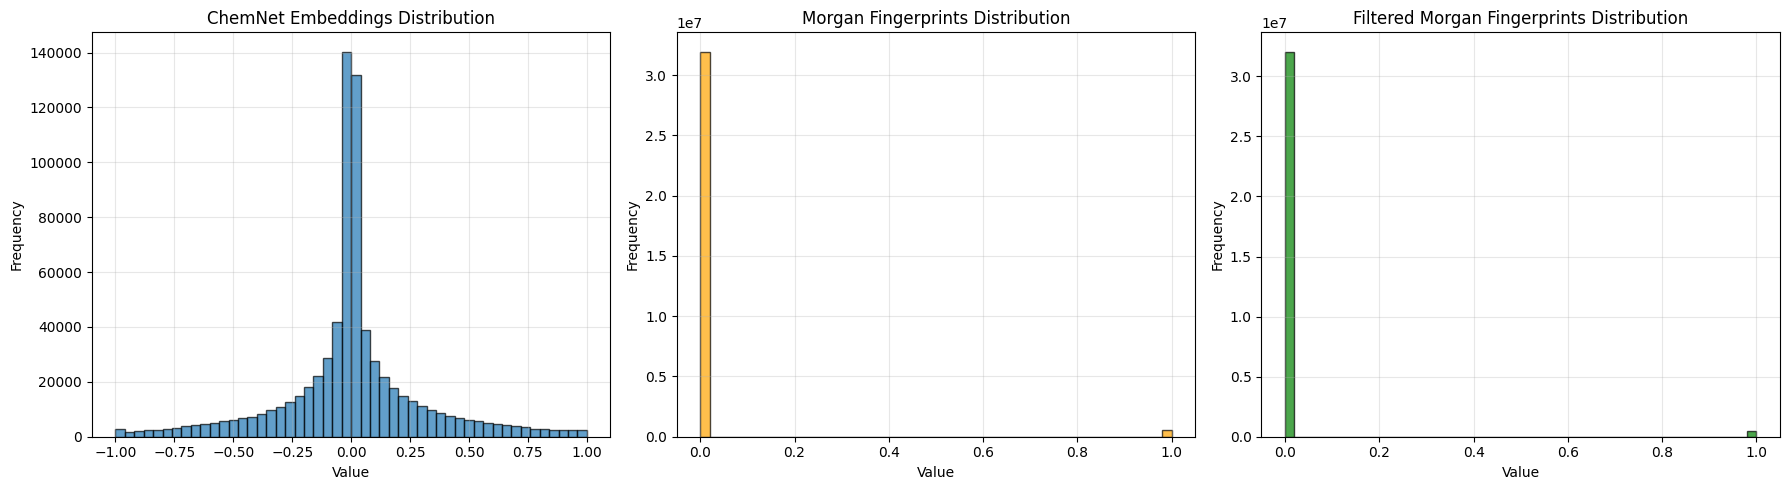

In [5]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram for name_smiles_embedding_df (ChemNet Embeddings)
numerical_cols = name_smiles_embedding_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = name_smiles_embedding_df[numerical_cols].values.flatten()
    axes[0].hist(values, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title('ChemNet Embeddings Distribution')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)

# Histogram for morgan_df (Morgan Fingerprints)
numerical_cols = morgan_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = morgan_df[numerical_cols].values.flatten()
    axes[1].hist(values, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_title('Morgan Fingerprints Distribution')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

# Histogram for filtered_morgan_df (Filtered Morgan Fingerprints)
numerical_cols = filtered_morgan_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = filtered_morgan_df[numerical_cols].values.flatten()
    axes[2].hist(values, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[2].set_title('Filtered Morgan Fingerprints Distribution')
    axes[2].set_xlabel('Value')
    axes[2].set_ylabel('Frequency')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== name_smiles_embedding_df_noise (ChemNet Embeddings with Noise) ===
Shape: (1419, 513)
Min value: -4.836056
Max value: 4.805108
Mean value: 0.004867

=== morgan_df_noise (Morgan Fingerprints with Noise) ===
Shape: (15869, 2049)
Min value: 0.000000
Max value: 6.223601
Mean value: 0.711510

=== filtered_morgan_df_noise (Filtered Morgan Fingerprints with Noise) ===
Shape: (15869, 2049)
Min value: 0.000000
Max value: 6.449114
Mean value: 0.709252



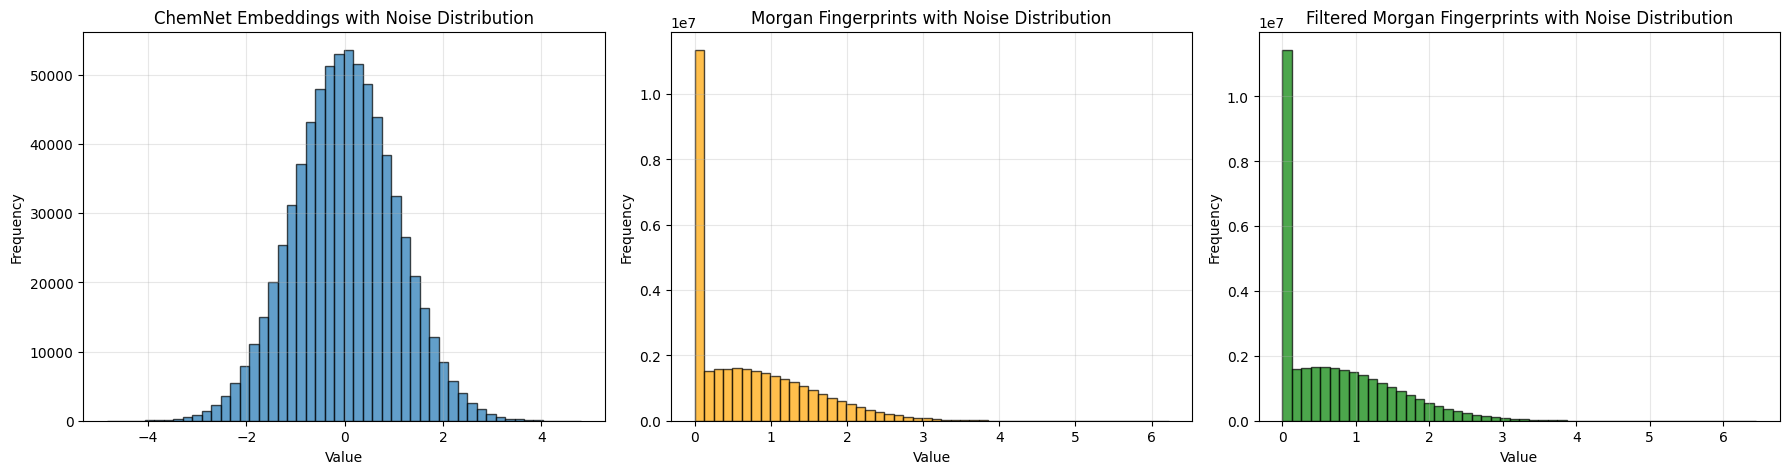


=== FILES SAVED ===
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet_noise.parquet
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp_noise.parquet
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp_noise.parquet


In [ ]:
# Create noisy versions of the dataframes

# 1. ChemNet embeddings with normal noise (mean=0, variance=1)
name_smiles_embedding_df_noise = name_smiles_embedding_df.copy()
numerical_cols = name_smiles_embedding_df_noise.select_dtypes(include=[np.number]).columns
noise = np.random.normal(loc=0, scale=1, size=name_smiles_embedding_df_noise[numerical_cols].shape)
name_smiles_embedding_df_noise[numerical_cols] = name_smiles_embedding_df_noise[numerical_cols] + noise

# 2. Morgan fingerprints with normal noise (mean=0.5, variance=1, no negatives)
morgan_df_noise = morgan_df.copy()
numerical_cols = morgan_df_noise.select_dtypes(include=[np.number]).columns
noise = np.random.normal(loc=0.5, scale=1, size=morgan_df_noise[numerical_cols].shape)
morgan_df_noise[numerical_cols] = morgan_df_noise[numerical_cols] + noise
morgan_df_noise[numerical_cols] = morgan_df_noise[numerical_cols].clip(lower=0)  # Exclude negative values

# 3. Filtered Morgan fingerprints with normal noise (mean=0.5, variance=1, no negatives)
filtered_morgan_df_noise = filtered_morgan_df.copy()
numerical_cols = filtered_morgan_df_noise.select_dtypes(include=[np.number]).columns
noise = np.random.normal(loc=0.5, scale=1, size=filtered_morgan_df_noise[numerical_cols].shape)
filtered_morgan_df_noise[numerical_cols] = filtered_morgan_df_noise[numerical_cols] + noise
filtered_morgan_df_noise[numerical_cols] = filtered_morgan_df_noise[numerical_cols].clip(lower=0)  # Exclude negative values

# Print details for each noisy dataframe
print("=== name_smiles_embedding_df_noise (ChemNet Embeddings with Noise) ===")
print(f"Shape: {name_smiles_embedding_df_noise.shape}")
numerical_cols = name_smiles_embedding_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {name_smiles_embedding_df_noise[numerical_cols].min().min():.6f}")
    print(f"Max value: {name_smiles_embedding_df_noise[numerical_cols].max().max():.6f}")
    print(f"Mean value: {name_smiles_embedding_df_noise[numerical_cols].mean().mean():.6f}")
print()

print("=== morgan_df_noise (Morgan Fingerprints with Noise) ===")
print(f"Shape: {morgan_df_noise.shape}")
numerical_cols = morgan_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {morgan_df_noise[numerical_cols].min().min():.6f}")
    print(f"Max value: {morgan_df_noise[numerical_cols].max().max():.6f}")
    print(f"Mean value: {morgan_df_noise[numerical_cols].mean().mean():.6f}")
print()

print("=== filtered_morgan_df_noise (Filtered Morgan Fingerprints with Noise) ===")
print(f"Shape: {filtered_morgan_df_noise.shape}")
numerical_cols = filtered_morgan_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {filtered_morgan_df_noise[numerical_cols].min().min():.6f}")
    print(f"Max value: {filtered_morgan_df_noise[numerical_cols].max().max():.6f}")
    print(f"Mean value: {filtered_morgan_df_noise[numerical_cols].mean().mean():.6f}")
print()

# Create histograms for the noisy dataframes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram for name_smiles_embedding_df_noise
numerical_cols = name_smiles_embedding_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = name_smiles_embedding_df_noise[numerical_cols].values.flatten()
    axes[0].hist(values, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title('ChemNet Embeddings with Noise Distribution')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)

# Histogram for morgan_df_noise
numerical_cols = morgan_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = morgan_df_noise[numerical_cols].values.flatten()
    axes[1].hist(values, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_title('Morgan Fingerprints with Noise Distribution')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

# Histogram for filtered_morgan_df_noise
numerical_cols = filtered_morgan_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = filtered_morgan_df_noise[numerical_cols].values.flatten()
    axes[2].hist(values, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[2].set_title('Filtered Morgan Fingerprints with Noise Distribution')
    axes[2].set_xlabel('Value')
    axes[2].set_ylabel('Frequency')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# # Save the noisy dataframes
# name_smiles_embedding_df_noise.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet_noise.parquet', index=False)
# morgan_df_noise.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp_noise.parquet', index=False)
# filtered_morgan_df_noise.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp_noise.parquet', index=False)

print("\n=== FILES SAVED ===")
print("Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet_noise.parquet")
print("Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp_noise.parquet")
print("Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp_noise.parquet")


=== FILES SAVED ===
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet_noise.parquet
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp_noise.parquet
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp_noise.parquet


# Super Test Set Composition

In [3]:

super_test_smiles = [
    'COC(=O)C=C(C)OP(=O)(OC)OC',
    'COc1cc2c(c3oc(=O)c4c(c13)CCC4=O)[C@@H]1C=CO[C@@H]1O2',
    'CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1',
    'C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[C@@H](O)C[C@H](O[C@H]4CC[C@@]5(C)[C@H](CC[C@@H]6[C@@H]5C[C@@H](O)[C@]5(C)[C@@H](C7=CC(=O)OC7)CC[C@]65O)C4)O[C@@H]3C)O[C@@H]2C)C[C@H](O)[C@@H]1O',
    'CNC(=O)Oc1cc(C)cc(C(C)C)c1',
    'CNC(=O)Oc1ccc(N(C)C)c(C)c1',
    'C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O)O)c(O)c2C(=O)O1',
    'COc1ccc2c(c1)c(CC(=O)OCC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1',
    'CC(C)(C)CC(C)(C)c1ccc(OCCOCC[N+](C)(C)Cc2ccccc2)cc1',
    'CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4ccc(Cl)cc4Cl)O3)cc2)CC1',
    'c1ccc(C2CN3CCSC3=N2)cc1',
    'CN(C)CCC=C1c2ccccc2CCc2ccccc21',
    'CCOP(=S)(OCC)Oc1ccc2c(C)c(Cl)c(=O)oc2c1',
    'CC(C)NCC(O)COc1cccc2ccccc12',
    'CCOC(=O)C(C)(C)Oc1ccc(Cl)cc1',
    'CCN(CC)CCNC(=O)c1cc(Cl)c(N)cc1OC',
    'COc1ccc2c(c1OC)C(=O)OC2C1c2cc3c(cc2CCN1C)OCO3',
    'CN(C)c1ccc(SC#N)cc1',
    'CC(C)[C@H](N)C(=O)O',
    'CCCCOC(=O)COC(=O)c1ccccc1C(=O)OCCCC',
    'NC(C(=O)O)c1ccccc1'
]

try:
    df6_spectra = df6_spectra
except NameError:
    df6_spectra = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')

super_test_df = df6_spectra[df6_spectra['SMILES_spectra'].isin(super_test_smiles)].copy()
super_test_df['tox_level'] = super_test_df['Response'].apply(fd.assign_tox_level)
result = super_test_df[['SMILES_spectra', 'tox_level', 'Response']].sort_values('Response')
result.reset_index(drop=True, inplace=True)
display(result)


,SMILES_spectra,tox_level,Response
0,CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1,tox_level_0,0.157898
1,CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1,tox_level_0,0.157898
2,CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1,tox_level_0,0.157898
3,CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1,tox_level_0,0.157898
4,COC(=O)C=C(C)OP(=O)(OC)OC,tox_level_0,3.000000
...,...,...,...
408,CCCCOC(=O)COC(=O)c1ccccc1C(=O)OCCCC,tox_level_4,7000.000000
409,CCCCOC(=O)COC(=O)c1ccccc1C(=O)OCCCC,tox_level_4,7000.000000
410,CCCCOC(=O)COC(=O)c1ccccc1C(=O)OCCCC,tox_level_4,7000.000000
411,CCCCOC(=O)COC(=O)c1ccccc1C(=O)OCCCC,tox_level_4,7000.000000


In [4]:
# Create a summary table: one row per unique SMILES, with count of spectra
summary_table = (
    super_test_df
    .groupby('SMILES_spectra', as_index=False)
    .agg(
        n_spectra=('SMILES_spectra', 'count'),
        Response=('Response', 'min')
    )
)
summary_table['tox_level'] = summary_table['Response'].apply(fd.assign_tox_level)
summary_table = summary_table[['SMILES_spectra', 'tox_level', 'Response', 'n_spectra']].sort_values('Response').reset_index(drop=True)
display(summary_table)

,SMILES_spectra,tox_level,Response,n_spectra
0,CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1,tox_level_0,0.157898,4
1,COC(=O)C=C(C)OP(=O)(OC)OC,tox_level_0,3.000000,14
2,COc1cc2c(c3oc(=O)c4c(c13)CCC4=O)[C@@H]1C=CO[C@...,tox_level_0,4.800000,10
3,C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O...,tox_level_1,19.524000,12
4,COc1ccc2c(c1)c(CC(=O)OCC(=O)O)c(C)n2C(=O)c1ccc...,tox_level_1,24.200000,20
5,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[...,tox_level_1,28.270000,8
6,CNC(=O)Oc1ccc(N(C)C)c(C)c1,tox_level_1,29.979859,6
7,CNC(=O)Oc1cc(C)cc(C(C)C)c1,tox_level_1,34.975166,6
8,CCOP(=S)(OCC)Oc1ccc2c(C)c(Cl)c(=O)oc2c1,tox_level_2,56.000000,21
9,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,tox_level_2,166.000000,30


In [5]:
# Filter for tox level 0 and 1 chemicals in df6_subset and summarize as before
df6_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')
df6_subset['tox_level'] = df6_subset['Response'].apply(fd.assign_tox_level)
filtered = df6_subset[df6_subset['tox_level'].isin(['tox_level_0', 'tox_level_1'])]

summary_lowtox = (
    filtered
    .groupby('SMILES_spectra', as_index=False)
    .agg(
        n_spectra=('SMILES_spectra', 'count'),
        Response=('Response', 'min')
    )
)
summary_lowtox['tox_level'] = summary_lowtox['Response'].apply(fd.assign_tox_level)
summary_lowtox = summary_lowtox[['SMILES_spectra', 'tox_level', 'Response', 'n_spectra']].sort_values('Response').reset_index(drop=True)
display(summary_lowtox)

,SMILES_spectra,tox_level,Response,n_spectra
0,CCC1CN2CCc3cc(OC)c(OC)cc3C2CC1CC1NCCc2cc(OC)c(...,tox_level_0,0.011991,11
1,CCOP(C)(=O)SCCN(C(C)C)C(C)C,tox_level_0,0.012000,14
2,Clc1cc2c(cc1Cl)Oc1cc(Cl)c(Cl)cc1O2,tox_level_0,0.020000,13
3,CC(OP(C)(=O)F)C(C)(C)C,tox_level_0,0.044500,14
4,CC(C)OC(=O)CCCC=CCC1C(O)CC(O)C1CCC(O)CCc1ccccc1,tox_level_0,0.049964,2
...,...,...,...,...
96,CCC(=O)N(c1ccccc1)C1(COC)CCN(CCn2nnn(CC)c2=O)CC1,tox_level_1,47.000000,14
97,CN1CCCC1c1cccnc1,tox_level_1,49.962924,14
98,CC1CCC2(OC1)OC1C(O)C3C4CCC5CC(OC6OC(CO)C(OC7OC...,tox_level_1,49.969472,7
99,CCS(=O)CCSP(=O)(OC)OC,tox_level_1,50.000000,14


In [6]:
# Replace this path with your desired dataframe path
df_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop/cond_enc_bin1_thresh0_05_df_spectra_loop0.parquet"

# Load the dataframe
df_pred = pd.read_parquet(df_path)

# Ensure the dataframe has columns: 'SMILES_spectra', 'Response', and 'predicted_class'
# If predicted_class is not already in tox_level format, convert as needed:
# For example, if predicted_class is a numeric response, use fd.assign_tox_level
if not df_pred['cond_tox_pred_class'].astype(str).str.startswith('tox_level_').all():
    df_pred['cond_tox_pred_class'] = df_pred['cond_tox_pred_class'].apply(fd.assign_tox_level)
else:
    df_pred['cond_tox_pred_class'] = df_pred['cond_tox_pred_class']

# Assign true tox_level
df_pred['tox_level'] = df_pred['Response'].apply(fd.assign_tox_level)

# Mark if prediction is correct
df_pred['correct'] = (df_pred['tox_level'] == df_pred['cond_tox_pred_class'])

# Group and summarize
summary_pred = (
    df_pred
    .groupby('SMILES_spectra', as_index=False)
    .agg(
        n_spectra=('SMILES_spectra', 'count'),
        Response=('Response', 'min'),
        tox_level=('tox_level', 'first'),
        predicted_level=('cond_tox_pred_class', 'first'),
        correct=('correct', 'first')
    )
)
summary_pred = summary_pred[['SMILES_spectra', 'tox_level', 'Response', 'n_spectra', 'predicted_level', 'correct']].sort_values('Response').reset_index(drop=True)
display(summary_pred)

,SMILES_spectra,tox_level,Response,n_spectra,predicted_level,correct
0,CCC1CN2CCc3cc(OC)c(OC)cc3C2CC1CC1NCCc2cc(OC)c(...,tox_level_0,0.011991,11,tox_level_0,True
1,CCOP(C)(=O)SCCN(C(C)C)C(C)C,tox_level_0,0.012000,10,tox_level_0,True
2,Clc1cc2c(cc1Cl)Oc1cc(Cl)c(Cl)cc1O2,tox_level_0,0.020000,10,tox_level_0,True
3,CC(OP(C)(=O)F)C(C)(C)C,tox_level_0,0.044500,10,tox_level_0,True
4,CP(=O)(F)OC1CCCCC1,tox_level_0,0.225000,10,tox_level_0,True
...,...,...,...,...,...,...
1047,CNC(=O)Oc1c(C(C)(C)C)cc(C)cc1C(C)(C)C,tox_level_4,34574.578265,6,tox_level_0,False
1048,OCC1OC(OC2C(CO)OC(O)C(O)C2O)C(O)C(O)C1O,tox_level_4,34781.619932,29,tox_level_0,False
1049,CSCCC(N)C(=O)O,tox_level_4,35960.444939,49,tox_level_0,False
1050,CSCC[C@H](N)C(=O)O,tox_level_4,36000.000000,17,tox_level_0,False


In [11]:
# Filter summary_pred to only include tox_level 0 and 1
summary_pred_filtered = summary_pred[summary_pred['tox_level'].isin(['tox_level_0', 'tox_level_1'])].reset_index(drop=True)
display(summary_pred_filtered)

,SMILES_spectra,tox_level,Response,n_spectra,predicted_level,correct
0,CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1,tox_level_0,0.157898,320,tox_level_0,True
1,COC(=O)C=C(C)OP(=O)(OC)OC,tox_level_0,3.000000,70,tox_level_0,True
2,COc1cc2c(c3oc(=O)c4c(c13)CCC4=O)[C@@H]1C=CO[C@...,tox_level_0,4.800000,800,tox_level_0,True
3,C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O...,tox_level_1,19.524000,960,tox_level_0,False
4,COc1ccc2c(c1)c(CC(=O)OCC(=O)O)c(C)n2C(=O)c1ccc...,tox_level_1,24.200000,1600,tox_level_0,False
5,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[...,tox_level_1,28.270000,640,tox_level_0,False
6,CNC(=O)Oc1ccc(N(C)C)c(C)c1,tox_level_1,29.979859,480,tox_level_0,False
7,CNC(=O)Oc1cc(C)cc(C(C)C)c1,tox_level_1,34.975166,480,tox_level_0,False


In [14]:
import pandas as pd

# Path to the actual parquet file (update this to the correct file if needed)
df_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop/cond_enc_bin0_1_thresh0_5_df_spectra_loop0.parquet"

# Load the dataframe
df_pred = pd.read_parquet(df_path)

# Ensure the predicted class column is correct
if not df_pred['cond_tox_pred_class'].astype(str).str.startswith('tox_level_').all():
    df_pred['cond_tox_pred_class'] = df_pred['cond_tox_pred_class'].apply(fd.assign_tox_level)

df_pred['tox_level'] = df_pred['Response'].apply(fd.assign_tox_level)
df_pred['correct'] = (df_pred['tox_level'] == df_pred['cond_tox_pred_class'])

# Filter for tox_level 0 and 1 only
df_pred_filtered = df_pred[df_pred['tox_level'].isin(['tox_level_0', 'tox_level_1'])].reset_index(drop=True)

# Select only the relevant columns
cols_to_keep = ['SMILES_spectra', 'cond_tox_pred_class', 'tox_level', 'train', 'correct']
df_pred_filtered = df_pred_filtered[cols_to_keep]

display(df_pred_filtered)


,SMILES_spectra,cond_tox_pred_class,tox_level,train,correct
0,C=C(C)[C@H]1Cc2c(ccc3c2O[C@@H]2COc4cc(OC)c(OC)...,tox_level_0,tox_level_1,1,False
1,C=C(C)[C@H]1Cc2c(ccc3c2O[C@@H]2COc4cc(OC)c(OC)...,tox_level_0,tox_level_1,1,False
2,C=C(C)[C@H]1Cc2c(ccc3c2O[C@@H]2COc4cc(OC)c(OC)...,tox_level_0,tox_level_1,1,False
3,C=C1CCC(O)CC1=CC=C1CCCC2(C)C1CCC2C(C)CCCC(C)C,tox_level_0,tox_level_1,1,False
4,C=C1CCC(O)CC1=CC=C1CCCC2(C)C1CCC2C(C)CCCC(C)C,tox_level_0,tox_level_1,1,False
...,...,...,...,...,...
831,O=c1oc2ccccc2c(O)c1C1CC(c2ccc(-c3ccc(Br)cc3)cc...,tox_level_0,tox_level_0,0,True
832,O=c1oc2ccccc2c(O)c1C1CC(c2ccc(-c3ccc(Br)cc3)cc...,tox_level_0,tox_level_0,0,True
833,O=c1oc2ccccc2c(O)c1C1CCCc2ccccc21,tox_level_0,tox_level_1,0,False
834,O=c1oc2ccccc2c(O)c1C1CCCc2ccccc21,tox_level_0,tox_level_1,0,False


In [4]:
import pandas as pd
import os
from pathlib import Path

# Directory containing the datasets
data_dir = Path('/home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop_super_test')

# Function to analyze datasets for a given bin and threshold
def analyze_spectra_performance(bin_value, threshold_value):
    """
    Analyze all loop files for a given bin and threshold combination.
    Returns a dataframe with each spectrum's performance across all loops.
    """
    # Pattern for files matching this bin and threshold
    if bin_value == '0_1':
        pattern = f'super_test_cond_enc_bin0_1_thresh{threshold_value}_df_spectra_loop*.parquet'
    else:
        pattern = f'super_test_cond_enc_bin{bin_value}_thresh{threshold_value}_df_spectra_loop*.parquet'
    
    # Get all matching files
    files = sorted(data_dir.glob(pattern))
    
    if not files:
        print(f"No files found for bin={bin_value}, threshold={threshold_value}")
        return None
    
    print(f"Found {len(files)} files for bin={bin_value}, threshold={threshold_value}")
    
    # Store all dataframes
    all_dfs = []
    
    # Read all files
    for file in files:
        df = pd.read_parquet(file)
        all_dfs.append(df)
    
    # Combine all dataframes with loop number
    combined_data = []
    
    for idx, df in enumerate(all_dfs):
        df_copy = df.copy()
        df_copy['loop_number'] = idx
        combined_data.append(df_copy)
    
    full_df = pd.concat(combined_data, ignore_index=True)
    
    # Group by smiles_spectra to calculate performance
    # Identify the relevant columns
    print(f"\nColumns in data: {full_df.columns.tolist()}")
    
    # Determine the correct column names (may vary)
    smiles_col = 'smiles_spectra' if 'smiles_spectra' in full_df.columns else 'smiles'
    
    # Group by spectrum and calculate statistics
    grouped = full_df.groupby(smiles_col)
    
    results = []
    
    for spectra, group in grouped:
        # Get the most common values (they should be consistent across loops)
        true_class = group['true_class'].mode()[0] if 'true_class' in group.columns else group['true'].mode()[0]
        response = group['response'].mode()[0] if 'response' in group.columns else None
        predicted_class = group['predicted_class'].mode()[0] if 'predicted_class' in group.columns else group['predicted'].mode()[0]
        
        # Calculate percentage correct across all dataframes
        if 'correct' in group.columns:
            correct_count = group['correct'].sum()
        else:
            # Calculate correct if not already in data
            correct_count = (group[group.columns[group.columns.str.contains('true')][0]] == 
                           group[group.columns[group.columns.str.contains('pred')][0]]).sum()
        
        total_count = len(group)
        percentage_correct = (correct_count / total_count) * 100
        
        results.append({
            'SMILES_spectra': spectra,
            'true_class': true_class,
            'response': response,
            'predicted_class': predicted_class,
            'correct_indicator': correct_count > 0,  # At least one correct
            'percentage_correct': percentage_correct,
            'num_dataframes': total_count
        })
    
    result_df = pd.DataFrame(results)
    
    # Sort by percentage_correct descending
    result_df = result_df.sort_values('percentage_correct', ascending=False)
    
    return result_df

# Example usage - you can change these parameters
bin_value = '1'  # Options: '0_1', '1'
threshold_value = '0_05'  # Options: '0_05', '0_5'

print(f"Analyzing bin={bin_value}, threshold={threshold_value}\n")
results_df = analyze_spectra_performance(bin_value, threshold_value)

if results_df is not None:
    print(f"\nTotal unique spectra: {len(results_df)}")
    print(f"\nFirst 20 results:")
    display(results_df.head(20))
    
    # Summary statistics
    print(f"\nSummary Statistics:")
    print(f"Average percentage correct: {results_df['percentage_correct'].mean():.2f}%")
    print(f"Median percentage correct: {results_df['percentage_correct'].median():.2f}%")
    print(f"# of spectra always correct (100%): {(results_df['percentage_correct'] == 100).sum()}")
    print(f"# of spectra never correct (0%): {(results_df['percentage_correct'] == 0).sum()}")

Analyzing bin=1, threshold=0_05

Found 25 files for bin=1, threshold=0_05

Columns in data: ['cond_emb_0', 'cond_emb_1', 'cond_emb_2', 'cond_emb_3', 'cond_emb_4', 'cond_emb_5', 'cond_emb_6', 'cond_emb_7', 'cond_emb_8', 'cond_emb_9', 'cond_emb_10', 'cond_emb_11', 'cond_emb_12', 'cond_emb_13', 'cond_emb_14', 'cond_emb_15', 'cond_emb_16', 'cond_emb_17', 'cond_emb_18', 'cond_emb_19', 'cond_emb_20', 'cond_emb_21', 'cond_emb_22', 'cond_emb_23', 'cond_emb_24', 'cond_emb_25', 'cond_emb_26', 'cond_emb_27', 'cond_emb_28', 'cond_emb_29', 'cond_emb_30', 'cond_emb_31', 'cond_emb_32', 'cond_emb_33', 'cond_emb_34', 'cond_emb_35', 'cond_emb_36', 'cond_emb_37', 'cond_emb_38', 'cond_emb_39', 'cond_emb_40', 'cond_emb_41', 'cond_emb_42', 'cond_emb_43', 'cond_emb_44', 'cond_emb_45', 'cond_emb_46', 'cond_emb_47', 'cond_emb_48', 'cond_emb_49', 'cond_emb_50', 'cond_emb_51', 'cond_emb_52', 'cond_emb_53', 'cond_emb_54', 'cond_emb_55', 'cond_emb_56', 'cond_emb_57', 'cond_emb_58', 'cond_emb_59', 'cond_emb_60', 'c

KeyError: 'smiles'

In [2]:
# First, let's check the structure of one file
test_file = '/home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop_super_test/super_test_cond_enc_bin1_thresh0_05_df_spectra_loop0.parquet'
df_test = pd.read_parquet(test_file)
print("Columns:", df_test.columns.tolist())
print("\nShape:", df_test.shape)
print("\nFirst 3 rows:")
display(df_test.head(3))

Columns: ['cond_emb_0', 'cond_emb_1', 'cond_emb_2', 'cond_emb_3', 'cond_emb_4', 'cond_emb_5', 'cond_emb_6', 'cond_emb_7', 'cond_emb_8', 'cond_emb_9', 'cond_emb_10', 'cond_emb_11', 'cond_emb_12', 'cond_emb_13', 'cond_emb_14', 'cond_emb_15', 'cond_emb_16', 'cond_emb_17', 'cond_emb_18', 'cond_emb_19', 'cond_emb_20', 'cond_emb_21', 'cond_emb_22', 'cond_emb_23', 'cond_emb_24', 'cond_emb_25', 'cond_emb_26', 'cond_emb_27', 'cond_emb_28', 'cond_emb_29', 'cond_emb_30', 'cond_emb_31', 'cond_emb_32', 'cond_emb_33', 'cond_emb_34', 'cond_emb_35', 'cond_emb_36', 'cond_emb_37', 'cond_emb_38', 'cond_emb_39', 'cond_emb_40', 'cond_emb_41', 'cond_emb_42', 'cond_emb_43', 'cond_emb_44', 'cond_emb_45', 'cond_emb_46', 'cond_emb_47', 'cond_emb_48', 'cond_emb_49', 'cond_emb_50', 'cond_emb_51', 'cond_emb_52', 'cond_emb_53', 'cond_emb_54', 'cond_emb_55', 'cond_emb_56', 'cond_emb_57', 'cond_emb_58', 'cond_emb_59', 'cond_emb_60', 'cond_emb_61', 'cond_emb_62', 'cond_emb_63', 'cond_emb_64', 'cond_emb_65', 'cond_emb_

,cond_emb_0,cond_emb_1,cond_emb_2,cond_emb_3,cond_emb_4,cond_emb_5,cond_emb_6,cond_emb_7,cond_emb_8,cond_emb_9,...,tox_level_4,Group,CE_clean,train,cond_tox_logit_0,cond_tox_logit_1,cond_tox_logit_2,cond_tox_logit_3,cond_tox_logit_4,cond_tox_pred_class
0,0.027878,0.311217,0.135045,-0.278578,-0.167444,0.058961,0.133080,-0.039557,0.140302,0.743140,...,0,LTQ-Orbitrap-positive,medium,0,13.047687,-16.699741,-6.737770,-12.160824,-6.262238,0
1,0.027831,0.311514,0.135324,-0.279118,-0.167416,0.058878,0.132895,-0.039414,0.140568,0.744009,...,0,LTQ-Orbitrap-positive,medium,0,13.070660,-16.735298,-6.760141,-12.184567,-6.263293,0
2,-0.017084,0.037230,-0.028332,0.079570,-0.147484,0.089736,-0.033014,-0.194176,-0.097741,-0.095844,...,0,LTQ-Orbitrap-positive,high,0,-0.473413,-0.849697,-0.413444,0.341929,0.282898,3


In [3]:
# Get relevant column names that might contain our data
all_cols = df_test.columns.tolist()

# Find columns that might be relevant
relevant_cols = [col for col in all_cols if any(keyword in col.lower() for keyword in 
                 ['smile', 'spectra', 'true', 'pred', 'class', 'correct', 'response', 'tox'])]

print("Relevant columns found:")
for col in relevant_cols:
    print(f"  - {col}")

Relevant columns found:
  - SMILES_spectra
  - Response
  - log_response
  - tox_level_0
  - tox_level_1
  - tox_level_2
  - tox_level_3
  - tox_level_4
  - cond_tox_logit_0
  - cond_tox_logit_1
  - cond_tox_logit_2
  - cond_tox_logit_3
  - cond_tox_logit_4
  - cond_tox_pred_class


In [5]:
import pandas as pd
import os
from pathlib import Path

# Directory containing the datasets
data_dir = Path('/home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop_super_test')

def analyze_spectra_performance(bin_value, threshold_value):
    """
    Analyze all loop files for a given bin and threshold combination.
    Returns a dataframe with each spectrum's performance across all loops.
    """
    # Pattern for files matching this bin and threshold
    if bin_value == '0_1':
        pattern = f'super_test_cond_enc_bin0_1_thresh{threshold_value}_df_spectra_loop*.parquet'
    else:
        pattern = f'super_test_cond_enc_bin{bin_value}_thresh{threshold_value}_df_spectra_loop*.parquet'
    
    # Get all matching files
    files = sorted(data_dir.glob(pattern))
    
    if not files:
        print(f"No files found for bin={bin_value}, threshold={threshold_value}")
        return None
    
    print(f"Found {len(files)} files for bin={bin_value}, threshold={threshold_value}")
    
    # Store all dataframes
    all_dfs = []
    
    # Read all files
    for file in files:
        df = pd.read_parquet(file)
        # Extract true class from one-hot encoded columns
        tox_cols = ['tox_level_0', 'tox_level_1', 'tox_level_2', 'tox_level_3', 'tox_level_4']
        df['true_class'] = df[tox_cols].values.argmax(axis=1)
        # Calculate if prediction is correct
        df['correct'] = (df['true_class'] == df['cond_tox_pred_class']).astype(int)
        all_dfs.append(df)
    
    # Combine all dataframes with loop number
    combined_data = []
    
    for idx, df in enumerate(all_dfs):
        df_copy = df.copy()
        df_copy['loop_number'] = idx
        combined_data.append(df_copy)
    
    full_df = pd.concat(combined_data, ignore_index=True)
    
    print(f"Total rows across all loops: {len(full_df)}")
    
    # Group by spectrum and calculate statistics
    grouped = full_df.groupby('SMILES_spectra')
    
    results = []
    
    for spectra, group in grouped:
        # Get the most common values (they should be consistent across loops)
        true_class = group['true_class'].mode()[0]
        predicted_class = group['cond_tox_pred_class'].mode()[0] 
        response = group['Response'].mode()[0] if 'Response' in group.columns else None
        
        # Calculate percentage correct across all dataframes
        correct_count = group['correct'].sum()
        total_count = len(group)
        percentage_correct = (correct_count / total_count) * 100
        
        results.append({
            'SMILES_spectra': spectra,
            'true_class': true_class,
            'Response': response,
            'predicted_class': predicted_class,
            'correct': correct_count > 0,  # At least one correct
            'percentage_correct': percentage_correct,
            'num_dataframes': total_count,
            'times_correct': correct_count,
            'times_incorrect': total_count - correct_count
        })
    
    result_df = pd.DataFrame(results)
    
    # Sort by percentage_correct descending
    result_df = result_df.sort_values('percentage_correct', ascending=False)
    
    return result_df

# Example usage - you can change these parameters
bin_value = '1'  # Options: '0_1', '1'
threshold_value = '0_05'  # Options: '0_05', '0_5'

print(f"Analyzing bin={bin_value}, threshold={threshold_value}\n")
print("="*80)
results_df = analyze_spectra_performance(bin_value, threshold_value)

if results_df is not None:
    print(f"\nTotal unique spectra: {len(results_df)}")
    
    # Filter to show only requested columns
    display_cols = ['SMILES_spectra', 'true_class', 'Response', 'predicted_class', 'correct', 'percentage_correct']
    
    print(f"\nAll results (sorted by percentage correct):")
    display(results_df[display_cols])
    
    # Summary statistics
    print(f"\n" + "="*80)
    print(f"SUMMARY STATISTICS:")
    print(f"="*80)
    print(f"Average percentage correct: {results_df['percentage_correct'].mean():.2f}%")
    print(f"Median percentage correct: {results_df['percentage_correct'].median():.2f}%")
    print(f"# of spectra always correct (100%): {(results_df['percentage_correct'] == 100).sum()}")
    print(f"# of spectra never correct (0%): {(results_df['percentage_correct'] == 0).sum()}")
    print(f"# of spectra sometimes correct: {((results_df['percentage_correct'] > 0) & (results_df['percentage_correct'] < 100)).sum()}")

Analyzing bin=1, threshold=0_05

Found 25 files for bin=1, threshold=0_05
Total rows across all loops: 9450

Total unique spectra: 19

All results (sorted by percentage correct):


,SMILES_spectra,true_class,Response,predicted_class,correct,percentage_correct
14,COc1ccc2c(c1OC)C(=O)OC2C1c2cc3c(cc2CCN1C)OCO3,3,999.313738,3,True,94.800000
6,CCN(CC)CCNC(=O)c1cc(Cl)c(N)cc1OC,3,750.000000,3,True,90.944000
4,CC(C)[C@H](N)C(=O)O,3,2000.000000,3,True,81.428571
18,c1ccc(C2CN3CCSC3=N2)cc1,2,345.757190,2,True,79.000000
5,CCCCOC(=O)COC(=O)c1ccccc1C(=O)OCCCC,4,7000.000000,4,True,72.666667
17,NC(C(=O)O)c1ccccc1,3,3027.962063,3,True,67.333333
7,CCOC(=O)C(C)(C)Oc1ccc(Cl)cc1,3,937.555988,3,True,65.600000
15,C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O...,1,19.524000,1,True,62.333333
3,CC(C)NCC(O)COc1cccc2ccccc12,3,660.000000,3,True,60.800000
13,COc1ccc2c(c1)c(CC(=O)OCC(=O)O)c(C)n2C(=O)c1ccc...,1,24.200000,1,True,54.600000



SUMMARY STATISTICS:
Average percentage correct: 44.57%
Median percentage correct: 54.60%
# of spectra always correct (100%): 0
# of spectra never correct (0%): 2
# of spectra sometimes correct: 17


In [7]:
# ========== CONFIGURABLE PARAMETERS ==========
# Change these values to analyze different bin/threshold combinations

BIN_VALUE = '0_1'      # Options: '0_1', '1'
THRESHOLD_VALUE = '0_5'  # Options: '0_05', '0_5'

# ============================================== 

print(f"Analyzing bin={BIN_VALUE}, threshold={THRESHOLD_VALUE}\n")
print("="*80)
results_df = analyze_spectra_performance(BIN_VALUE, THRESHOLD_VALUE)

if results_df is not None:
    print(f"\nTotal unique spectra: {len(results_df)}")
    
    # Filter to show only requested columns
    display_cols = ['SMILES_spectra', 'true_class', 'Response', 'predicted_class', 'correct', 'percentage_correct']
    
    print(f"\nAll results (sorted by percentage correct):")
    display(results_df[display_cols])
    
    # Summary statistics
    print(f"\n" + "="*80)
    print(f"SUMMARY STATISTICS:")
    print(f"="*80)
    print(f"Average percentage correct: {results_df['percentage_correct'].mean():.2f}%")
    print(f"Median percentage correct: {results_df['percentage_correct'].median():.2f}%")
    print(f"# of spectra always correct (100%): {(results_df['percentage_correct'] == 100).sum()}")
    print(f"# of spectra never correct (0%): {(results_df['percentage_correct'] == 0).sum()}")
    print(f"# of spectra sometimes correct: {((results_df['percentage_correct'] > 0) & (results_df['percentage_correct'] < 100)).sum()}")
    
    # Optionally save to CSV
    # output_filename = f'spectra_analysis_bin{BIN_VALUE}_thresh{THRESHOLD_VALUE}.csv'
    # results_df[display_cols].to_csv(output_filename, index=False)
    # print(f"\nResults saved to: {output_filename}")

Analyzing bin=0_1, threshold=0_5

Found 5 files for bin=0_1, threshold=0_5
Total rows across all loops: 2065

Total unique spectra: 21

All results (sorted by percentage correct):


,SMILES_spectra,true_class,Response,predicted_class,correct,percentage_correct
14,COc1cc2c(c3oc(=O)c4c(c13)CCC4=O)[C@@H]1C=CO[C@...,0,4.800000,0,True,100.000000
6,CCN(CC)CCNC(=O)c1cc(Cl)c(N)cc1OC,3,750.000000,3,True,91.840000
3,CC(C)NCC(O)COc1cccc2ccccc12,3,660.000000,3,True,90.500000
7,CCOC(=O)C(C)(C)Oc1ccc(Cl)cc1,3,937.555988,3,True,88.000000
16,COc1ccc2c(c1OC)C(=O)OC2C1c2cc3c(cc2CCN1C)OCO3,3,999.313738,3,True,78.000000
19,NC(C(=O)O)c1ccccc1,3,3027.962063,3,True,75.833333
4,CC(C)[C@H](N)C(=O)O,3,2000.000000,3,True,48.571429
8,CCOP(=S)(OCC)Oc1ccc2c(C)c(Cl)c(=O)oc2c1,2,413.000000,3,True,39.047619
17,C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O...,1,19.524000,3,True,33.333333
9,CN(C)CCC=C1c2ccccc2CCc2ccccc21,2,276.900411,3,True,28.888889



SUMMARY STATISTICS:
Average percentage correct: 35.18%
Median percentage correct: 15.00%
# of spectra always correct (100%): 1
# of spectra never correct (0%): 4
# of spectra sometimes correct: 16


In [33]:
import pandas as pd
from pathlib import Path
from scipy import stats

# ========== CONFIGURABLE PARAMETERS ==========
BIN_VALUE = '1'           # Options: '0_1', '1'
THRESHOLD_VALUE = '0_05'  # Options: '0_05', '0_5'
NUM_LOOPS = 25            # Number of loop files to analyze (set to None for all files)
# ==============================================

data_dir = Path('/home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop_super_test')

# Build pattern for files
if BIN_VALUE == '0_1':
    pattern = f'super_test_cond_enc_bin0_1_thresh{THRESHOLD_VALUE}_df_spectra_loop*.parquet'
else:
    pattern = f'super_test_cond_enc_bin{BIN_VALUE}_thresh{THRESHOLD_VALUE}_df_spectra_loop*.parquet'

# Get all matching files
files = sorted(data_dir.glob(pattern))
print(f"Found {len(files)} total files for bin={BIN_VALUE}, threshold={THRESHOLD_VALUE}")

# Limit to specified number of loops if provided
if NUM_LOOPS is not None:
    files = files[:NUM_LOOPS]
    print(f"Using first {len(files)} loop files\n")
else:
    print(f"Using all {len(files)} loop files\n")

# Load first file to get spectra counts per SMILES
first_df = pd.read_parquet(files[0])
tox_cols = ['tox_level_0', 'tox_level_1', 'tox_level_2', 'tox_level_3', 'tox_level_4']
first_df['true_class'] = first_df[tox_cols].values.argmax(axis=1)
spectra_per_smiles = first_df.groupby('SMILES_spectra').size().to_dict()

# Load all dataframes
all_dfs = []
for file in files:
    df = pd.read_parquet(file)
    # Calculate true class from one-hot encoding
    df['true_class'] = df[tox_cols].values.argmax(axis=1)
    all_dfs.append(df)

# Combine all dataframes
combined_df = pd.concat(all_dfs, ignore_index=True)
print(f"Total rows: {len(combined_df)}\n")

# Group by SMILES_spectra and aggregate
results = []
for smiles, group in combined_df.groupby('SMILES_spectra'):
    true_class = group['true_class'].iloc[0]
    
    # Most common predicted class
    predicted_class = stats.mode(group['cond_tox_pred_class'], keepdims=False)[0]
    
    # Proportion correct
    correct_count = (group['cond_tox_pred_class'] == true_class).sum()
    total_count = len(group)
    proportion_correct = correct_count / total_count
    
    # Number of spectra for this SMILES in one dataframe
    num_spectra = spectra_per_smiles.get(smiles, 0)
    
    results.append({
        'SMILES_spectra': smiles,
        'num_spectra': num_spectra,
        'true_class': true_class,
        'predicted_class': predicted_class,
        'proportion_correct': proportion_correct
    })

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('true_class', ascending=True).reset_index(drop=True)

print(f"Analysis complete for bin={BIN_VALUE}, threshold={THRESHOLD_VALUE}, loops={NUM_LOOPS if NUM_LOOPS else 'all'}")
print(f"Total unique SMILES: {len(results_df)}\n")
display(results_df)

Found 25 total files for bin=1, threshold=0_05
Using first 25 loop files

Total rows: 9825

Analysis complete for bin=1, threshold=0_05, loops=25
Total unique SMILES: 21



,SMILES_spectra,num_spectra,true_class,predicted_class,proportion_correct
0,CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1,4,0,3,0.200000
1,COc1cc2c(c3oc(=O)c4c(c13)CCC4=O)[C@@H]1C=CO[C@...,10,0,0,0.472000
2,COC(=O)C=C(C)OP(=O)(OC)OC,4,0,3,0.000000
3,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[...,8,1,3,0.045000
4,C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O...,12,1,1,0.610000
5,COc1ccc2c(c1)c(CC(=O)OCC(=O)O)c(C)n2C(=O)c1ccc...,20,1,1,0.562000
6,CNC(=O)Oc1ccc(N(C)C)c(C)c1,6,1,3,0.000000
7,CNC(=O)Oc1cc(C)cc(C(C)C)c1,6,1,3,0.000000
8,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,30,2,3,0.156000
9,CN(C)c1ccc(SC#N)cc1,6,2,3,0.000000


In [30]:
# Filter to only include tox levels 0 and 1
results_df_filtered = results_df[results_df['true_class'].isin([0, 1])].reset_index(drop=True)

print(f"Filtered to tox levels 0 and 1 only")
print(f"Total spectra with tox level 0 or 1: {len(results_df_filtered)}\n")
display(results_df_filtered)

Filtered to tox levels 0 and 1 only
Total spectra with tox level 0 or 1: 7



,SMILES_spectra,num_spectra,true_class,predicted_class,proportion_correct
0,CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1,4,0,3,0.160000
1,COc1cc2c(c3oc(=O)c4c(c13)CCC4=O)[C@@H]1C=CO[C@...,10,0,0,0.396000
2,C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[...,8,1,3,0.045000
3,C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O...,12,1,1,0.623333
4,COc1ccc2c(c1)c(CC(=O)OCC(=O)O)c(C)n2C(=O)c1ccc...,20,1,1,0.546000
5,CNC(=O)Oc1ccc(N(C)C)c(C)c1,6,1,3,0.000000
6,CNC(=O)Oc1cc(C)cc(C(C)C)c1,6,1,3,0.000000


In [31]:
# Check one file to see unique SMILES count
test_file = '/home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop_super_test/super_test_cond_enc_bin1_thresh0_05_df_spectra_loop0.parquet'
df_check = pd.read_parquet(test_file)

print(f"File: {test_file.split('/')[-1]}")
print(f"Total rows: {len(df_check)}")
print(f"Unique SMILES_spectra: {df_check['SMILES_spectra'].nunique()}")
print(f"\nAll unique SMILES in this file:")
for i, smiles in enumerate(sorted(df_check['SMILES_spectra'].unique()), 1):
    print(f"{i}. {smiles}")

File: super_test_cond_enc_bin1_thresh0_05_df_spectra_loop0.parquet
Total rows: 393
Unique SMILES_spectra: 21

All unique SMILES in this file:
1. CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4ccc(Cl)cc4Cl)O3)cc2)CC1
2. CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1
3. CC(C)(C)CC(C)(C)c1ccc(OCCOCC[N+](C)(C)Cc2ccccc2)cc1
4. CC(C)NCC(O)COc1cccc2ccccc12
5. CC(C)[C@H](N)C(=O)O
6. CCCCOC(=O)COC(=O)c1ccccc1C(=O)OCCCC
7. CCN(CC)CCNC(=O)c1cc(Cl)c(N)cc1OC
8. CCOC(=O)C(C)(C)Oc1ccc(Cl)cc1
9. CCOP(=S)(OCC)Oc1ccc2c(C)c(Cl)c(=O)oc2c1
10. CN(C)CCC=C1c2ccccc2CCc2ccccc21
11. CN(C)c1ccc(SC#N)cc1
12. CNC(=O)Oc1cc(C)cc(C(C)C)c1
13. CNC(=O)Oc1ccc(N(C)C)c(C)c1
14. COC(=O)C=C(C)OP(=O)(OC)OC
15. COc1cc2c(c3oc(=O)c4c(c13)CCC4=O)[C@@H]1C=CO[C@@H]1O2
16. COc1ccc2c(c1)c(CC(=O)OCC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1
17. COc1ccc2c(c1OC)C(=O)OC2C1c2cc3c(cc2CCN1C)OCO3
18. C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O)O)c(O)c2C(=O)O1
19. C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[C@@H](O)C[C@H](O[C@H]4CC[C@@]5(C)[C@H](CC[

In [34]:
import pandas as pd

# File 1: Training/validation data
parquet_file1 = '/home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop/cond_enc_bin1_thresh0_05_df_spectra_loop0.parquet'
csv_file1 = '/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_bin1_thresh0_05_df_spectra_loop0.csv'

df1 = pd.read_parquet(parquet_file1)
df1.to_csv(csv_file1, index=False)
print(f"Converted {parquet_file1}")
print(f"  Shape: {df1.shape}")
print(f"  Saved to: {csv_file1}")

# File 2: Super test data
parquet_file2 = '/home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop_super_test/super_test_cond_enc_bin1_thresh0_05_df_spectra_loop0.parquet'
csv_file2 = '/home/dlipsey/MITLincolnLabs/MIT_LL_data/super_test_cond_enc_bin1_thresh0_05_df_spectra_loop0.csv'

df2 = pd.read_parquet(parquet_file2)
df2.to_csv(csv_file2, index=False)
print(f"\nConverted {parquet_file2}")
print(f"  Shape: {df2.shape}")
print(f"  Saved to: {csv_file2}")

print("\nBoth files converted successfully!")

Converted /home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop/cond_enc_bin1_thresh0_05_df_spectra_loop0.parquet
  Shape: (14859, 4624)
  Saved to: /home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_bin1_thresh0_05_df_spectra_loop0.csv

Converted /home/dlipsey/MITLincolnLabs/MIT_LL_data/2step_cond_enc_134_loop_super_test/super_test_cond_enc_bin1_thresh0_05_df_spectra_loop0.parquet
  Shape: (393, 4626)
  Saved to: /home/dlipsey/MITLincolnLabs/MIT_LL_data/super_test_cond_enc_bin1_thresh0_05_df_spectra_loop0.csv

Both files converted successfully!
